# ERA5 Reanalysis: Data Processing & Plots

*Last updated April 28, 2026*

Here, we explore ERA5 reanalysis data obtained from the [ECMWF Climate Data Store (CDS)](https://cds.climate.copernicus.eu/). We make use of the [CDS API](https://pypi.org/project/cdsapi/) to automatically download the data required given API requests generated by the CDS browser app.  

In [1]:
import os
import zipfile

import cdsapi

import numpy as np
import pandas as pd 
import xarray as xr
from xmovie import Movie

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import matplotlib.pyplot as plt
from matplotlib import ticker

plt.rcParams["figure.figsize"] = (8,6)
plt.rc("font", family="serif")

%matplotlib inline

First, we define some helper functions for downloading/loading our CDS data as xArray datasets. 

In [2]:
def load_data_from_existing(directory):
    """ 
    Load an xarray dataset from a given existing directory. 
    """
    return xr.load_dataset(
        directory + "/data.grib", 
        engine = "cfgrib",
        decode_timedelta = True,
    )

def download_zipped_data(dataset = "", request = {}):
    """
    Downloads a zip archive from the Climate Data Store 
    from a given dataset and a given request. 

    The correct syntax for a particular request dict
    can be obtained using the CDS browser app 
    (just click the data product you want, check off
    the dates, vars, etc. you want, and the site 
    will spit out the request you can paste into your
    code)
    """
    client = cdsapi.Client()
    
    # the client.retrieve().download() method returns the filename of the zip archive
    zipfilename = client.retrieve(dataset, request).download()
    return zipfilename

def unzip_data(path_to_zipfile, out_directory):
    """
    Extracts a zipfile at path_to_zipfile to a new dir called out_directory.
    """
    with zipfile.ZipFile(path_to_zipfile, 'r') as zip_ref:
        zip_ref.extractall(out_directory)
    return None 
    
def get_ds(directory, dataset = "", request = {}):
    """
    Get the xarray dataset from a particular directory, 
    or download it if it doesn't already exist on your path.
    """
    if not os.path.isdir(directory):
        zipfilename = download_zipped_data(dataset, request)
        unzip_data(zipfilename, directory)
    return load_data_from_existing(directory)    

Next, we define a helpful function to streamline plotting. 

Since we want to have one function that produces all of our plots, we must accept a **lot** of kwargs! However, matplotlib's functions all have too many kwargs, so we're only committing the sins everyone else commits. 

In [4]:
def draw_na_map(
    lon, 
    lat, 
    field_vals, 
    title = None, 
    filled = False, 
    show_fig = True, 
    save_fig = False, 
    levels = 8,
    cmap = "plasma",
    cbar_params = [0.95, 0.2, 0.05, 0.6],
    label_mtl = False,
    bbox = None,
    vmin = None, 
    vmax = None,
    label_contours = True, 
    remove_cbar = False,
    fig = None,
    wind_velocity = [None, None],
    wind_velocity_grain = 1, 
):
    """
    Produces a (possibly filled) contour plot of a scalar field with gridded lat/lon values 
    "field_vals" overlaid on a map of most of North America. 
    """
    # Draw annotated map of North America
    if fig is None: 
        fig, ax = plt.subplots(
            1, 
            1,
            figsize=(8, 6),
            subplot_kw={"projection": ccrs.PlateCarree()}
        )

    else: 
        ax = fig.subplots(
            1,
            subplot_kw={"projection": ccrs.PlateCarree()}
        )

    # Draw coastlines
    ax.coastlines()

    # Draw national and state/province borders
    states = cfeature.NaturalEarthFeature(
        category="cultural", 
        name="admin_1_states_provinces_lines",
        scale="50m", 
        facecolor="none",
    )
    
    ax.add_feature(
        states, 
        linewidth=0.5, 
        edgecolor="black",
    )
    
    ax.add_feature(
        cfeature.BORDERS, 
        linestyle="-",
    )

    # Draw lake borders
    lakes = cfeature.NaturalEarthFeature(
        "physical", 
        "lakes", 
        scale="50m",
        edgecolor="k", 
        facecolor="none",
    )
    
    ax.add_feature(lakes)

    # Make gridlines and label them
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": 14, "color": "k"}
    gl.ylabel_style = {"size": 14, "color": "k"}

    # Draw contour plot
    my_levels = np.linspace(vmin, vmax, levels + 1, endpoint = True) if (vmin is not None and vmax is not None) else levels 
    
    if filled: 
        co = ax.contourf(
            lon,
            lat,
            field_vals,
            transform = ccrs.PlateCarree(),
            levels = my_levels,
            cmap = cmap,
            vmin = vmin,
            vmax = vmax, 
        )
        
    else: 
        co = ax.contour(
            lon,
            lat,
            field_vals,
            transform = ccrs.PlateCarree(),
            levels = my_levels,
            cmap = cmap,
            vmin = vmin,
            vmax = vmax, 
        )

    # Label the contours on the plot if desired. 
    # We don't allow contour labels if we're drawing a filled plot!
    if not filled and label_contours: 
        ax.clabel(co, co.levels, fontsize=10)

    # Title
    if title: 
        plt.title(title, fontsize=16)

    # Draw colorbar
    cbar_ax = fig.add_axes(cbar_params)
    cbar = plt.colorbar(co, cax = cbar_ax)

    if vmin is not None and vmax is not None:
        cbar.mappable.set_clim(vmin, vmax)

    # Remove colorbar if desired 
    if remove_cbar:
        cbar.remove() 

    # Zoom in if required
    if bbox is not None: 
        ax.set_extent(bbox)

    # Add wind barbs if wind velocity makes sense 
    if all(velocity_component is not None for velocity_component in wind_velocity):
        ax.barbs(lon[::wind_velocity_grain,], 
                 lat[::wind_velocity_grain,],
                 wind_velocity[0][::wind_velocity_grain, ::wind_velocity_grain], 
                 wind_velocity[1][::wind_velocity_grain, ::wind_velocity_grain],
                 color = "xkcd:dark magenta"         
        ) 

    # Mark Montreal with a star if required
    if label_mtl: 
        ax.plot(-73.568492, 45.508674, marker="o", color="xkcd:cerulean", markersize=10)
            
    # Save and/or display the figure
    if save_fig: 
        plt.savefig(title + ".png", dpi = 600, bbox_inches = "tight")

    if show_fig: 
        plt.show()

    return None

Now, we can load and inspect all the data we wish. 

In [5]:
na_data_dir = "na_data"
na_dataset = "reanalysis-era5-pressure-levels"
na_request = {
    "product_type": ["reanalysis"],
    "variable": [
        "geopotential",
        "u_component_of_wind",
        "v_component_of_wind",
    ], 
    "year": ["2023"],
    "month": ["04"],
    "day": ["03", "04", "05"],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "pressure_level": ["500", 
                       "600",
                       "700",
                       "800",
                       "900", 
                       "1000",
                      ],
    "data_format": "grib",
    "download_format": "zip",
    "area": [70, -125, 25, -50]
    }

ds_na = get_ds(na_data_dir, na_dataset, na_request)

In [6]:
na_surf_data_dir = "na_surf_data"

na_surf_dataset = "reanalysis-era5-single-levels"
na_surf_request = {
    "product_type": ["reanalysis"],
    "variable": [
        "mean_sea_level_pressure",
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
    ],
    "year": ["2023"],
    "month": ["04"],
    "day": ["03", "04", "05"],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "data_format": "grib",
    "download_format": "zip",
    "area": [70, -125, 25, -50]
}

ds_na_surf = get_ds(na_surf_data_dir, na_surf_dataset, na_surf_request)

In [12]:
# Add thickness (in dam) as a var
ds_na = ds_na.assign(th = -1e-1*(1/9.8)*(ds_na.sel(isobaricInhPa=1000.0)["z"] - ds_na.sel(isobaricInhPa=500.0)["z"]))

# Add wind speed (in km/h) as a var
ds_na_surf = ds_na_surf.assign(
    speed = 3.6 * np.sqrt(ds_na_surf["u10"]**2 + ds_na_surf["v10"]**2)
)

Now that we've got our reanalysis data, we can start drawing weather maps. These are crucial for comparing the 2023 ice storm to the classification in the paper of [Ressler et al.](https://journals.ametsoc.org/view/journals/wefo/27/2/waf-d-11-00071_1.xml). 

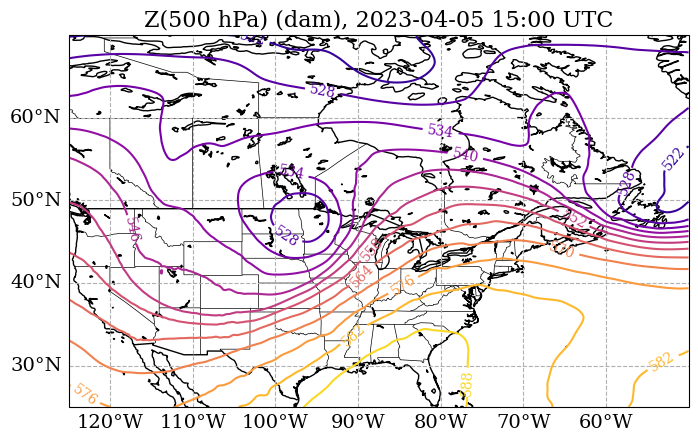

In [13]:
draw_na_map(
    ds_na["longitude"],
    ds_na["latitude"], 
    ds_na.sel(isobaricInhPa=500.0, time = "2023-04-05T15:00:00.000000000")["z"]/9.8/10,
    title= r"Z(500 hPa) (dam), 2023-04-05 15:00 UTC",
    cmap = "plasma", 
    levels = 12,
    show_fig = True,
    save_fig = False, 
    remove_cbar = True,
)

Note the trough inclined roughly on the line between Winnipeg and northwestern Mississippi. This means the 2023 Montreal ice storm is an "eastern event" according to the taxonomy of Ressler et al. 

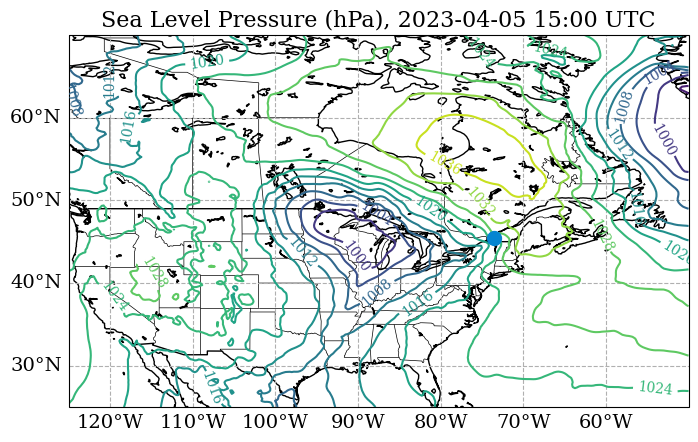

In [14]:
draw_na_map(
    ds_na_surf["longitude"],
    ds_na_surf["latitude"], 
    ds_na_surf.sel(time = "2023-04-05T15:00:00.000000000")["msl"]/100., # convert to hPa! 
    title= "Sea Level Pressure (hPa), 2023-04-05 15:00 UTC",
    cmap = "viridis", 
    levels = 12,
    show_fig = True,
    save_fig = False, 
    label_mtl = True, 
    remove_cbar = True,
)

Note the strong cyclone over the northern midwest/western Great Lakes region and the weak high over northern Quebec. 

To illustrate the effect of pressure-driven channeling, let's zoom in on the SLP plot and also display the (10 m) wind barbs. 

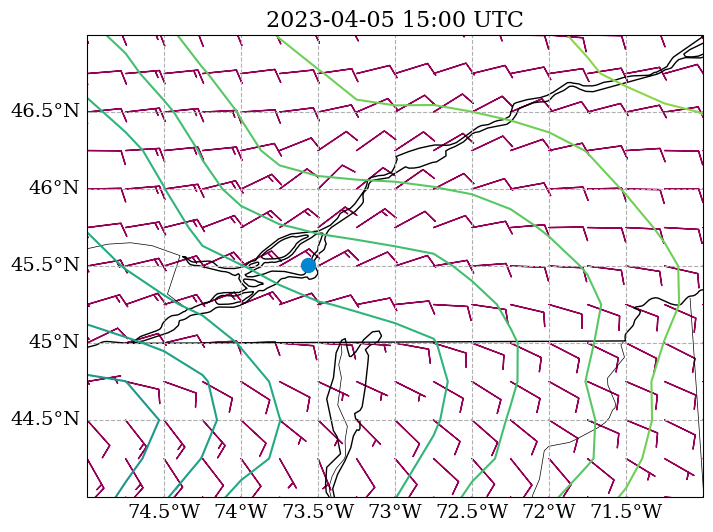

In [15]:
# Make sure to convert m/s [which CDS supplies] to kn!
surf_wind_velocity = [
     1.94384 * ds_na_surf.sel(time = "2023-04-05T15:00:00.000000000")["u10"].values,
     1.94384 * ds_na_surf.sel(time = "2023-04-05T15:00:00.000000000")["v10"].values,
]

draw_na_map(
    ds_na_surf["longitude"],
    ds_na_surf["latitude"], 
    ds_na_surf.sel(time = "2023-04-05T15:00:00.000000000")["msl"]/100., # convert to hPa! 
    title= "2023-04-05 15:00 UTC",
    cmap = "viridis",
    remove_cbar = True,
    bbox = [-75, -71, 44, 47],
    label_mtl = True, 
    label_contours = True,
    wind_velocity = surf_wind_velocity,  
    levels = 28,
    show_fig = True,
    save_fig = False, 
)

This plot clearly shows pressure-driven channeling giving rise to a non-geostrophic wind along the St. Lawrence valley. 

We can get a movie of the layer thickness' evolution using the xmovie package. This helps identify CAA/WAA. 

In [16]:
vmin = 490
vmax = 590

def custom_plotfunc(ds, fig, tt, *args, **kwargs):
    time = pd.to_datetime(str(ds.isel(time=tt).time.values)).strftime("%Y-%m-%d %H:00 UTC")
    draw_na_map(
        ds["longitude"], 
        ds["latitude"], 
        ds.isel(time=tt), 
        f"Layer Thickness (dam) {time}", 
        filled = False, 
        show_fig = False, 
        save_fig = False, 
        label_contours = False,
        levels = 16,
        cmap = "gist_heat",
        cbar_params = [0.82, 0.2, 0.02, 0.6],
        bbox = [-100, -55, 25, 60],
        vmin = vmin, 
        vmax = vmax,
        fig = fig,
    )
    return None, None

mov = Movie(
    ds_na["th"], 
    custom_plotfunc, 
    vmin = vmin, 
    vmax = vmax,
)

#Uncomment this if you want to save the movie! 
# mov.save(
#     "thickness.mp4", 
#     framerate = 8, 
#     overwrite_existing = True,)

We can also save stills of the thickness' evolution. 

In [17]:
vmin = 490
vmax = 590

my_time = "2023-04-04 15:00"

ds_uc = ds_na.sel(longitude = slice(-85, -72), latitude = slice(47., 40.))

mean_u = 1.94384 * ( 
    ds_uc.sel(time = my_time).mean(dim = "isobaricInhPa")["u"].values 
)

mean_v = 1.94384 * ( 
    ds_uc.sel(time = my_time).mean(dim = "isobaricInhPa")["v"].values 
)

mean_wind_velocity = [
     mean_u,
     mean_v,
]

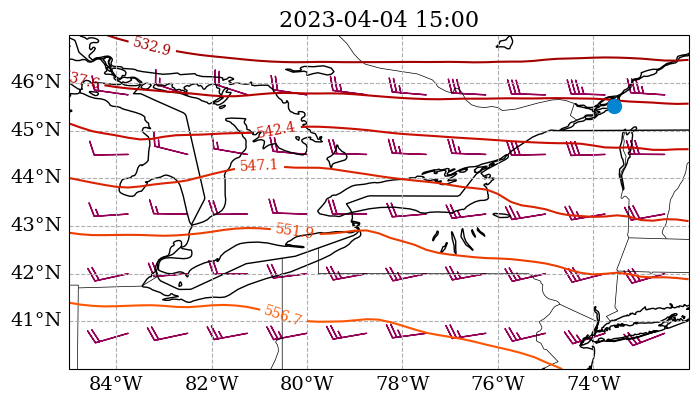

In [18]:
draw_na_map(
    ds_uc["longitude"], 
    ds_uc["latitude"], 
    ds_uc.sel(isobaricInhPa=500.0, time = my_time)["th"], 
    # "Layer Thickness (dam), " + f"{my_time}", 
    f"{my_time}", 
    filled = False, 
    show_fig = True, 
    save_fig = False, 
    levels = 21,
    cmap = "gist_heat",
    remove_cbar = True,
    cbar_params = [0.92, 0.2, 0.02, 0.6],
    vmin = vmin, 
    vmax = vmax,
    #bbox = [-85, -72, 40, 47],
    label_mtl = True, 
    wind_velocity = mean_wind_velocity,  
    wind_velocity_grain = 5,
)

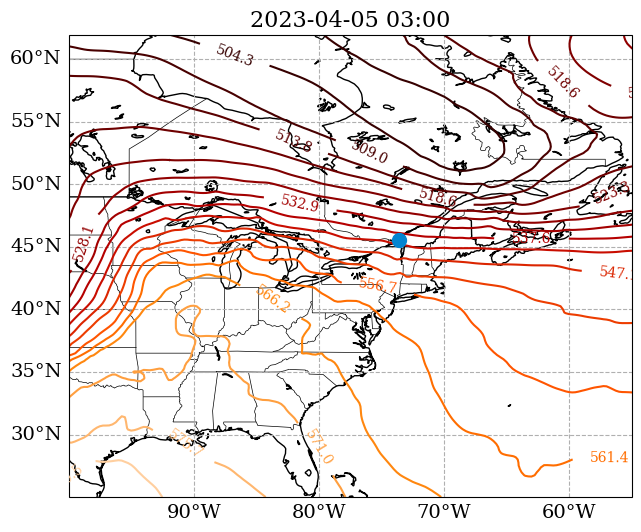

In [19]:
my_time = "2023-04-05 03:00"
draw_na_map(
    ds_na["longitude"], 
    ds_na["latitude"], 
    ds_na.sel(isobaricInhPa=500.0, time = my_time)["th"], 
    f"{my_time}", 
    filled = False, 
    show_fig = True, 
    save_fig = True, 
    levels = 21,
    cmap = "gist_heat",
    remove_cbar = True,
    cbar_params = [0.92, 0.2, 0.02, 0.6],
    vmin = vmin, 
    vmax = vmax,
    bbox = [-100, -55, 25, 60],
    label_mtl = True, 
)

We can also get a movie of the speed around Montreal, which is helpful for attempting a [SPIA classification](https://www.spia-index.com/). 

In [20]:
vmin = 0.
vmax = 44.

def custom_plotfunc(ds, fig, tt, *args, **kwargs):
    time = pd.to_datetime(str(ds.isel(time=tt).time.values)).strftime("%Y-%m-%d %H:00 UTC")
    draw_na_map(
        ds["longitude"], 
        ds["latitude"], 
        ds.isel(time=tt), 
        f"Surface Wind Speed (km/h), {time}", 
        filled = True, 
        show_fig = False, 
        save_fig = False, 
        levels = 20,
        cmap = "RdPu",
        cbar_params = [0.8, 0.2, 0.025, 0.6],
        label_mtl = True,
        bbox = [-80, -70, 40, 50],
        vmin = vmin, 
        vmax = vmax,
        fig = fig,
    )
    return None, None

mov = Movie(
    ds_na_surf.sel(time=slice("2023-04-05", "2023-04-06"))["speed"], 
    custom_plotfunc, 
    vmin = vmin, 
    vmax = vmax,
)

# Again, uncomment this if you want to make the movie. 
# mov.save(
#     "speed.mp4", 
#     framerate = 5, 
#     overwrite_existing = True,)

We can also estimate the maximum speed (in km/h) around Montreal during the storm. 

In [21]:
ds_na_surf.sel(
    latitude = slice(46.5, 45.),
    longitude = slice(-75., -72.),
    time=slice("2023-04-05", "2023-04-06"),
)["speed"].max().values

array(34.03964, dtype=float32)

Thus the renalysis predicts that the storm reaches a maximum speed of about $34$ km/h $\approx 21.1$ mph. This is a little lower than the maximum speed of $41$km/h measured at the St-Hubert station. 

Next, we obtain some additional *monthly* reanalysis data to build a 30-year winter 1000-500 hPa thickness climatology. Strictly speaking this is not the climatology used in Ressler et al., but in my opinion it is more appropriate to compare 2023 storms to the 1993-2022 climate rather than the 1979-2008 climate. 

In [22]:
na_clim_data_dir = "na_clim_data"
na_clim_dataset = "reanalysis-era5-pressure-levels-monthly-means"
na_clim_request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": ["geopotential"],
    "pressure_level": ["500", "1000"],
    "year": [
        "1993", "1994", "1995",
        "1996", "1997", "1998",
        "1999", "2000", "2001",
        "2002", "2003", "2004",
        "2005", "2006", "2007",
        "2008", "2009", "2010",
        "2011", "2012", "2013",
        "2014", "2015", "2016",
        "2017", "2018", "2019",
        "2020", "2021", "2022",
    ],
    "month": ["01", "02", "03", 
              "04",
              "10", "11", "12",
    ],
    "time": ["00:00"],
    "data_format": "grib",
    "download_format": "zip",
    "area": [70, -125, 25, -50]
}

ds_na_clim = get_ds(na_clim_data_dir, na_clim_dataset, na_clim_request)

In [23]:
ds_na_clim = ds_na_clim.assign(
    th = -1e-1*(1/9.8)*(ds_na_clim.sel(isobaricInhPa=1000.0)["z"] - ds_na_clim.sel(isobaricInhPa=500.0)["z"])
)
ds_na_clim = ds_na_clim.mean(dim="time")

In [24]:
anomaly = ds_na.sel(time = "2023-04-04T15:00:00.000000000")["th"] - ds_na_clim["th"]

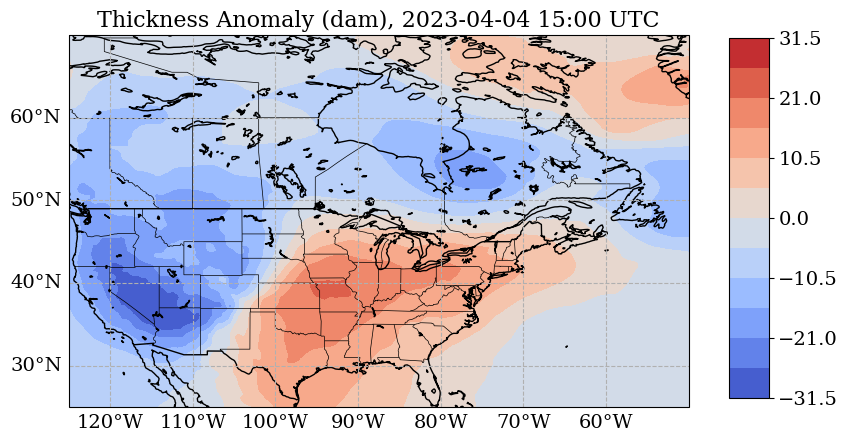

In [25]:
draw_na_map(
    ds_na_clim["longitude"],
    ds_na_clim["latitude"], 
    anomaly,
    title= "Thickness Anomaly (dam), 2023-04-04 15:00 UTC",
    filled = True,
    cmap = "coolwarm", 
    levels = 12,
    show_fig = True,
    save_fig = True,
    vmin = -31.5, 
    vmax = 31.5,
    label_contours = False, 
)

We note anomalous thickness (read: warmth!) over Southern Ontario as suggested by Ressler et al. for eastern storms! 